In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# import csv file
file_path = '..\\DataCleaning\\cleaned_dataset.csv'

try:
    df = pd.read_csv(file_path)
    print("File loaded successfully.")
except FileNotFoundError:
    print("File not found in the specified path.")
except PermissionError:
    print("Permission denied to read the file.")
except Exception as e:
    print(f"An error occurred: {e}")

File loaded successfully.


In [2]:
df.head()

,CustomerID,Name,Age,Gender,Location,Email,Phone,Address,Segment,NPS,...,ActionCount,unique_pages,most_recent_action_date,Logins,Frequency,Rating,Comment,AVGOpenDays,AVGClickDays,customer_segment
0,1001,Mark Barrett,31,Male,Andrewfort,allison74@example.net,3192528777,"61234 Shelley Heights Suite 467\nCohentown, GU...",Segment B,3,...,24,13,2022-11-07 02:24:31,19,Weekly,1,I move baby go small big. Office institution s...,818.0,319.0,at_risk
1,1002,Jeremy Welch,66,Female,Millerhaven,fmiller@example.com,231-587-1818x8651,"4959 Jennifer Junction\nNew Angelaport, TN 87397",Segment C,6,...,24,13,2022-12-05 00:27:08,9,Weekly,2,Wish what bag cut life. Statement might opport...,110.0,88.0,premium
2,1003,Brandon Patel,36,Female,Lozanostad,jasonbrown@example.org,(270)633-9095,"38701 Amanda Brook Apt. 076\nKimshire, NJ 62516",Segment B,3,...,12,7,2022-11-02 15:59:43,19,Monthly,4,Some Democrat guess but short. Whether behind ...,333.0,117.0,need_attention
3,1004,Tina Martin,62,Female,South Dustin,matthew62@example.net,050.081.8706x11982,"67324 Ashley Coves\nSouth John, RI 29650",Segment C,1,...,47,14,2022-12-08 18:10:18,4,Daily,1,Yard feel never miss ask billion Congress. Fly...,159.0,423.0,loyal
4,1005,Christopher Rodriguez,68,Female,West James,shannonstrickland@example.org,+1-701-854-4915x724,"01169 Miller Mission\nWest Anthonyburgh, WY 47359",Segment C,3,...,30,12,2022-12-30 23:37:00,12,Weekly,3,Ten determine unit interview challenge stock. ...,193.0,96.0,loyal


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12483 entries, 0 to 12482
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               12483 non-null  int64  
 1   Name                     12483 non-null  object 
 2   Age                      12483 non-null  int64  
 3   Gender                   12483 non-null  object 
 4   Location                 12483 non-null  object 
 5   Email                    12483 non-null  object 
 6   Phone                    12483 non-null  object 
 7   Address                  12483 non-null  object 
 8   Segment                  12483 non-null  object 
 9   NPS                      12483 non-null  int64  
 10  ChurnLabel               12483 non-null  int64  
 11  Timestamp                12483 non-null  object 
 12  TotalPurchaseFrequency   12483 non-null  int64  
 13  TotalPurchaseValue       12483 non-null  float64
 14  ProductList           

In [4]:
df.describe()

,CustomerID,Age,NPS,ChurnLabel,TotalPurchaseFrequency,TotalPurchaseValue,numEmails,numCalls,numChats,AVGLatePayment,NumPaymentMethods,PageViews,TimeSpent(minutes),ActionCount,unique_pages,Logins,Rating,AVGOpenDays,AVGClickDays
count,12483.00000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.0,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000,12483.000000
mean,7242.00000,43.930065,2.973884,0.505808,30.236962,2770.122997,6.838020,6.750300,6.779620,12.055516,3.0,50.634944,34.602499,25.604102,10.462149,15.561484,3.000641,362.010735,180.340303
std,3603.67604,15.341521,2.644623,0.499986,17.279633,1594.525110,5.871361,5.790698,5.828992,10.470468,0.0,28.930760,27.603618,14.414630,3.580320,8.694091,1.411094,320.591617,213.157204
min,1001.00000,18.000000,0.000000,0.000000,1.000000,12.270000,0.000000,0.000000,0.000000,0.000000,3.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,4121.50000,31.000000,1.000000,0.000000,16.000000,1425.160000,2.000000,2.000000,2.000000,2.666667,3.0,26.000000,14.000000,13.000000,9.000000,8.000000,2.000000,99.000000,28.000000
50%,7242.00000,44.000000,2.000000,1.000000,29.000000,2701.160000,5.000000,5.000000,5.000000,7.666667,3.0,51.000000,26.000000,26.000000,12.000000,16.000000,3.000000,266.000000,99.000000
75%,10362.50000,57.000000,4.000000,1.000000,43.000000,4011.355000,10.000000,10.000000,10.000000,21.666667,3.0,76.000000,51.000000,38.000000,13.000000,23.000000,4.000000,551.000000,257.000000
max,13483.00000,70.000000,9.000000,1.000000,79.000000,7552.800000,32.000000,31.000000,30.000000,39.000000,3.0,100.000000,103.000000,50.000000,14.000000,30.000000,5.000000,1454.000000,1367.000000


The insights we gain from the summary statistics above are:

1. Age: 
  - The mean age (43.93) is less than the median age (44) meaning that age is left-skewed.
  - The minimum age is 18 years old and the maximum age is 70 years old. 
  - The standard deviation is 15.34 which is relatively low meaning that most customers are aged close to the mean age of 43.93.
This shows that most customers are middle aged.

2. Total Purchase Value: 
  - The mean (2770.12) is significantly greater than the median (2701.16), meaning that the Total Purchase value is right-skewed.
  - The standard deviation (1594.53) is significantly high meaning that most customers total purchase value differ from the mean which suggests that there is possibility of outliers.
  - The minimum total purchase value is 12.27 and the maximum is 7552.8. This is a significantly large range which emphasises that there is possibility of outliers and suggest that there are some customers who have made very few purchases.

3. Average Late Payments: 
  - The mean (12.05) is significantly higher than the median (7.67), which suggests that the average late payments in the dataset is right-skewed.
  - The standard deviation (10.47) is significantly high meaning that the average late payments of most customers differ from the mean (12.05)
  - The minimum average late Payments is 0 while the maximum is 39. A significant range but suggests that there is possibility of some customers who are never make late payments.

4. PageViews: 
  - The mean (50.63) is slightly lower than the median (51) which suggests that it is slightly left-skewed.
  - The standard deviation (28.93) is relatively high meaning that most customers PageViews differ from the mean. There is possibility of a median mix of high and low page views.
  - The minimum number of PageViews is 1 and the maximum is 100. This is a significantly large range meaning that there is possibility of outliers and low engagement of some customers.

5. TimeSpent(minutes): 
  - The mean is 34.60 and the median is 26 meaning that the time spent on the website is right skewed.
  - The standard deviation (27.60) is significantly high meaning that Time Spent on the website by most of the customers differ from the mean.
  - The minimum time spent on the website is 1 minute while the maximum time spent is 103 minutes. This suggest possibility of outliers or low  engagement by some customers.

6. Logins: 
  - The mean (15.56) is slightly lower than the median (16) meaning that the number of logins is left-skewed.
  - The standard deviation is moderately high meaning that most customers number of logins differ from the mean.
  - The minimum number of number of logins is 1 and the maximum is 30 which suggests possibility of low engagement by some customers.

8. Rating:
  - The mean (3) is the same as the median (3). Given a scale of 5 this suggest a moderate rating which suggests that there's need for some improvement in the products sold.
  - The standard deviation (1.41) is low which suggests that most rating by the customers is close to the mean.
  - The minimum rating (1) and the maximum is 5. This suggests that there is possibility of low performing products which suggests a need for improvement.

9. Total Purchase Frequency:
  - The mean (30.24) is less than the median (29) meaning that the Total Purchase frequency is right-skewed.
  - The standard deviation (17.27) is relatively high which suggests that the total frequency of most customers differ from the mean.
  - The minimum rating (1) and the maximum is 79. This suggests that there is possibility of low engagement by some customers.


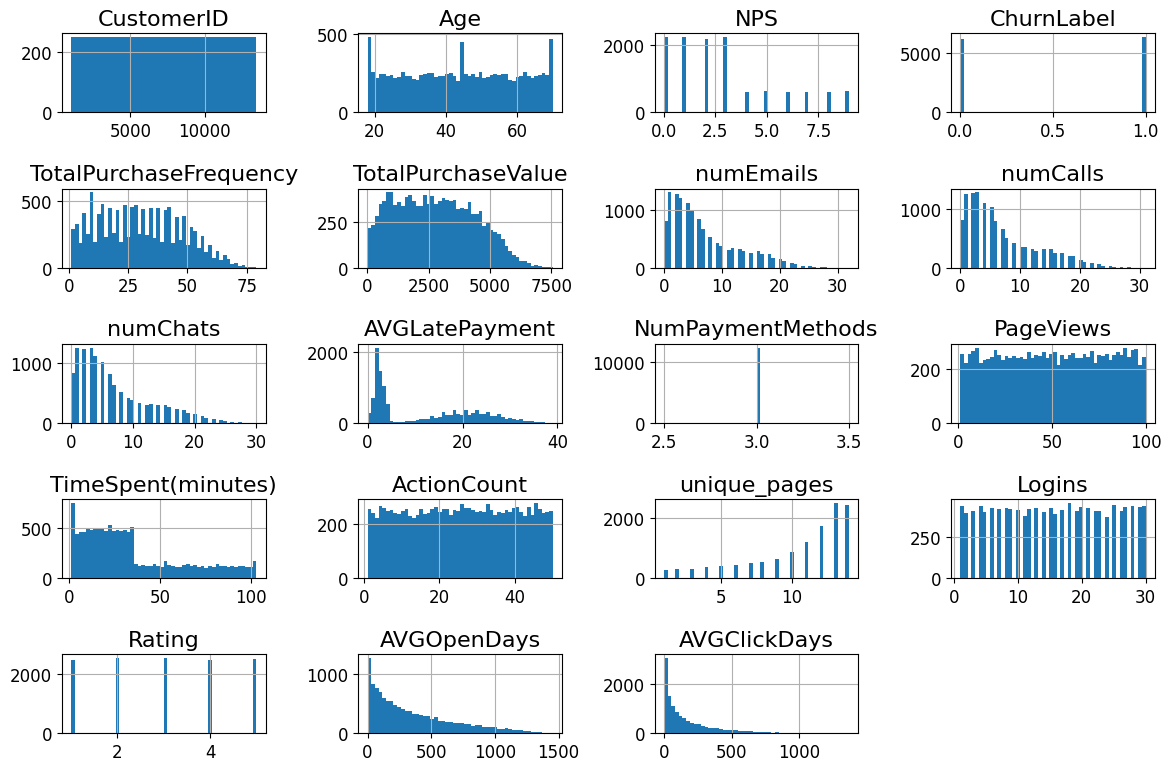

In [5]:
# Plot Histograms for continuous variables

import matplotlib.pyplot as plt
import seaborn as sns

plt.rc("font", size=16)
plt.rc("axes", labelsize=14, titlesize=16)
plt.rc("legend", fontsize=16)
plt.rc("xtick", labelsize=12)
plt.rc("ytick", labelsize=12)

df.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Customer Spending Distribution

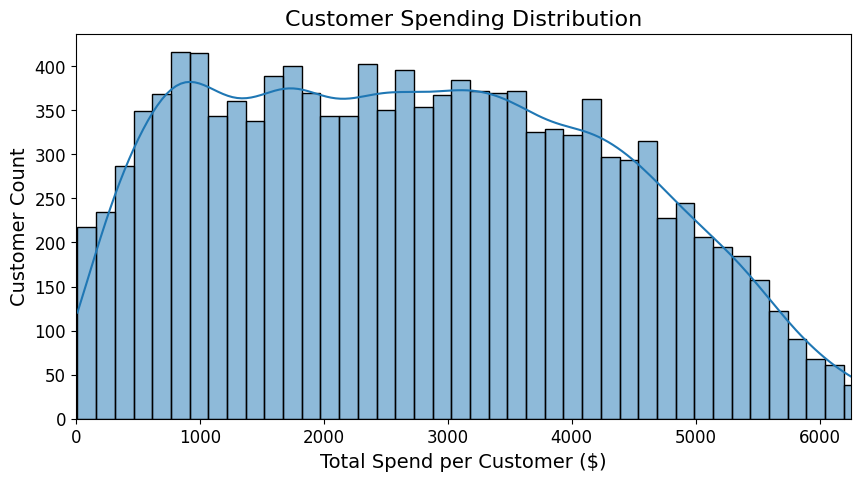

In [6]:
# Aggregate total spend per customer
customer_spend = df.groupby("CustomerID")["TotalPurchaseValue"].sum()

# Visualization: Customer Spending Distribution
plt.figure(figsize=(10,5))
sns.histplot(customer_spend, bins=50, kde=True)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spend per Customer ($)")
plt.ylabel("Customer Count")
plt.xlim(0, customer_spend.quantile(0.99))  # Remove extreme outliers
plt.show()

The key insights we gain from the customer spending distribution are:
    - The distribution is right skewed, with most customers spending between $0 and $4000
    - There is quite a significant amount of high spenders (>35000)
    - This suggests that there is a potential for growth. The presense of high spenders indicates the potential for increasing the average spending by implementing strategies to move low spenders to mid-value spending.


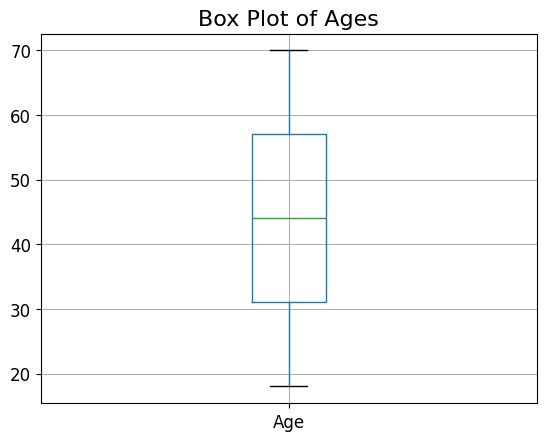

In [7]:
# Plot Boxplot for Age Variable
ax = df.boxplot(column='Age')
plt.title('Box Plot of Ages')
plt.show()

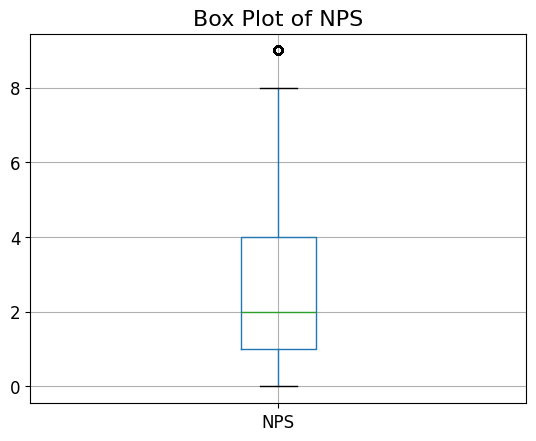

In [8]:
# Plot Boxplot for Age Variable
ax = df.boxplot(column='NPS')
plt.title('Box Plot of NPS')
plt.show()

The insight we gain from the NPS box plot is that there is a single outlier above 8
The IQR is 3 and the median is 2

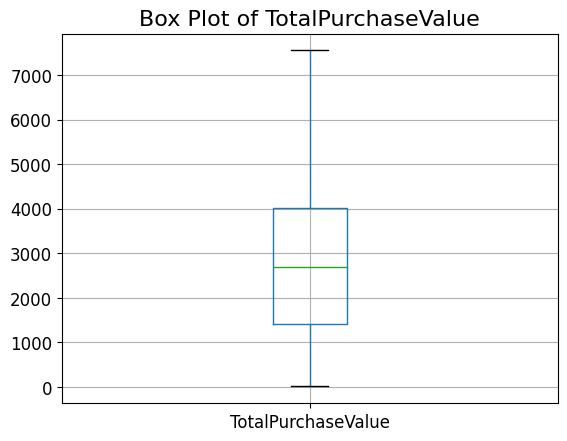

In [9]:
# Plot Boxplot for TotalPurchaseValue Variable
ax = df.boxplot(column='TotalPurchaseValue')
plt.title('Box Plot of TotalPurchaseValue')
plt.show()

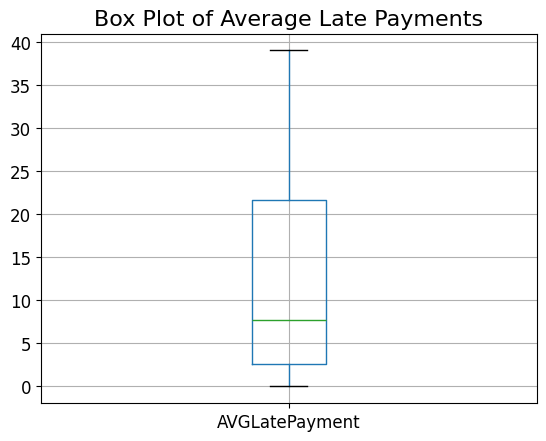

In [10]:
# Plot Boxplot for TotalLatePayments Variable
ax = df.boxplot(column='AVGLatePayment')
plt.title('Box Plot of Average Late Payments')
plt.show()

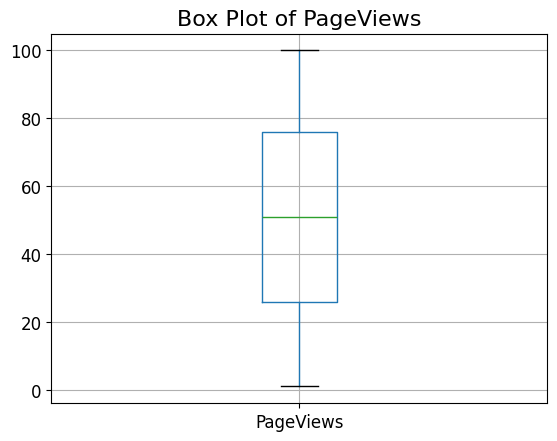

In [11]:
# Plot Boxplot for PageViews Variable
ax = df.boxplot(column='PageViews')
plt.title('Box Plot of PageViews')
plt.show()

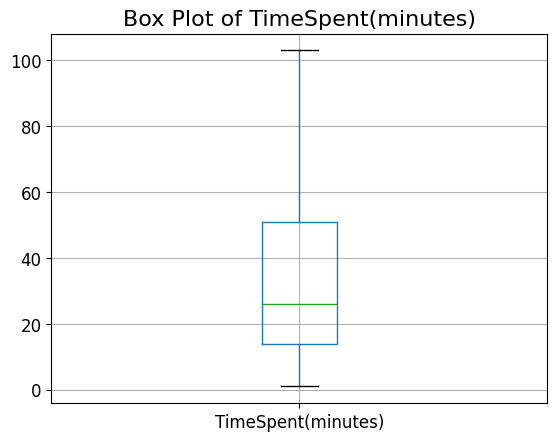

In [12]:
# Plot Boxplot for TimeSpentOnWebsite Variable
ax = df.boxplot(column='TimeSpent(minutes)')
plt.title('Box Plot of TimeSpent(minutes)')
plt.show()

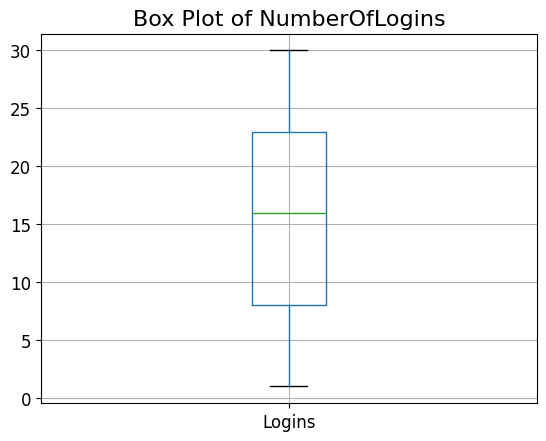

In [13]:
# Plot Boxplot for NumberOfLogins Variable
ax = df.boxplot(column='Logins')
plt.title('Box Plot of NumberOfLogins')
plt.show()

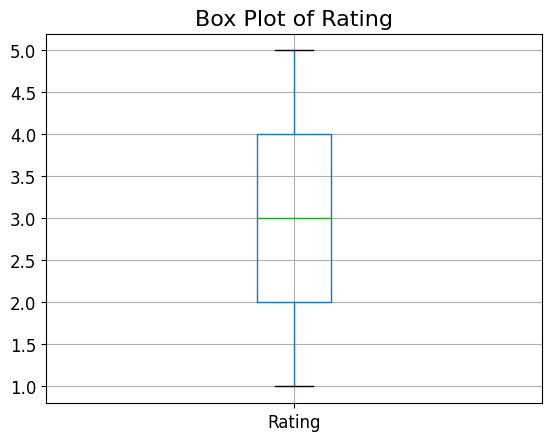

In [14]:
# Plot Boxplot for Rating Variable
ax = df.boxplot(column='Rating')
plt.title('Box Plot of Rating')
plt.show()

# Total Purchase Value

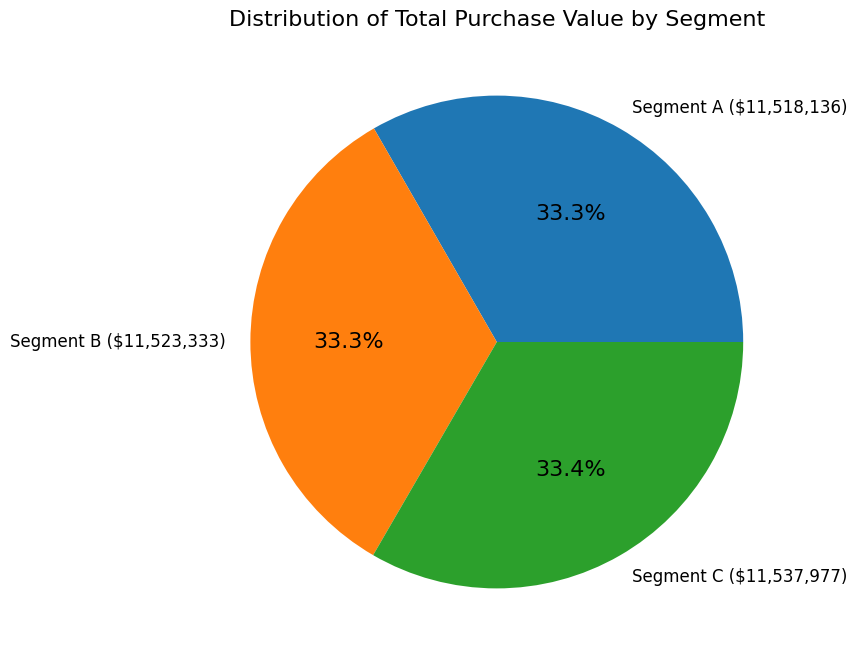

In [15]:
# Group by Segment and sum the TotalPurchaseValue
segment_sums = df.groupby('Segment')['TotalPurchaseValue'].sum()

# Plot a pie chart of TotalPurchaseValue against Segment
# Add totals to labels
labels = [f"{seg} (${val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Total Purchase Value by Segment')
plt.show()

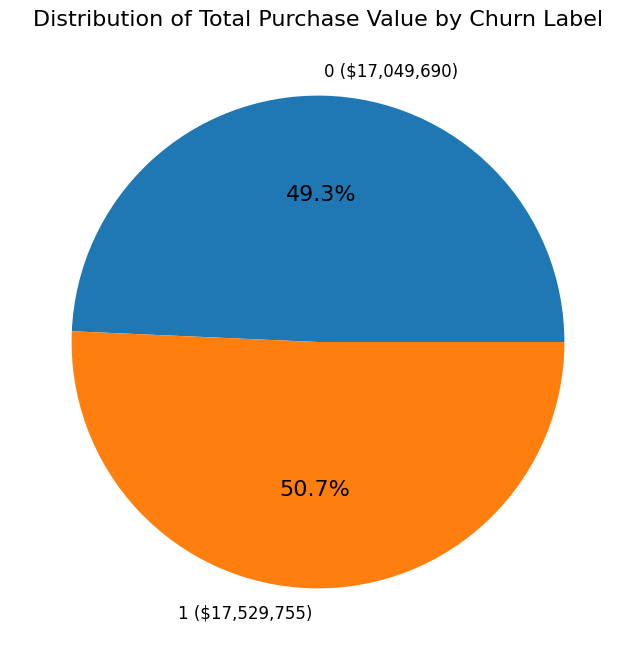

In [16]:
# Group by Churn Label and sum the TotalPurchaseValue
segment_sums = df.groupby('ChurnLabel')['TotalPurchaseValue'].sum()

# Plot a pie chart of TotalPurchaseValue against ChurnLabel
# Add totals to labels
labels = [f"{seg} (${val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Total Purchase Value by Churn Label')
plt.show()

The key insight we gain from the Distribution of Total Purchase Value by Segment:
    - The total purchase value by segment is significantly almost similar. Meaning that there is no dominant segment.

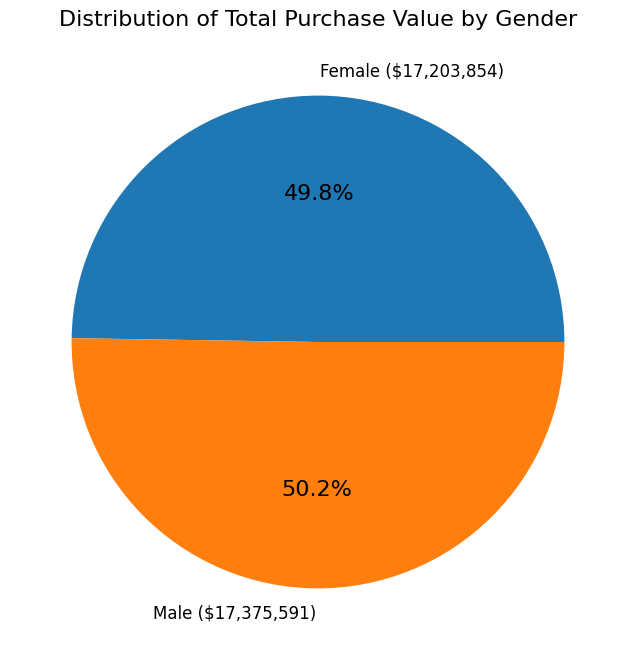

In [17]:
# Group by Gender and sum the TotalPurchaseValue
segment_sums = df.groupby('Gender')['TotalPurchaseValue'].sum()

# Plot a pie chart of TotalPurchaseValue against Segment
# Add totals to labels
labels = [f"{seg} (${val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Total Purchase Value by Gender')
plt.show()

The key insight we gain from the Distribution of Total Purchase Value by Gender is that:
    - The total purchase value is slightly dominated by males (50.4) as compared to females (49.6).

Based on the Total Purchase Value by Sibscription Plan bar plot the key insights we gain are that:
    - The highest total purchase value is from students.
    - The lowest is the Elite

# Time Spent (Minutes)

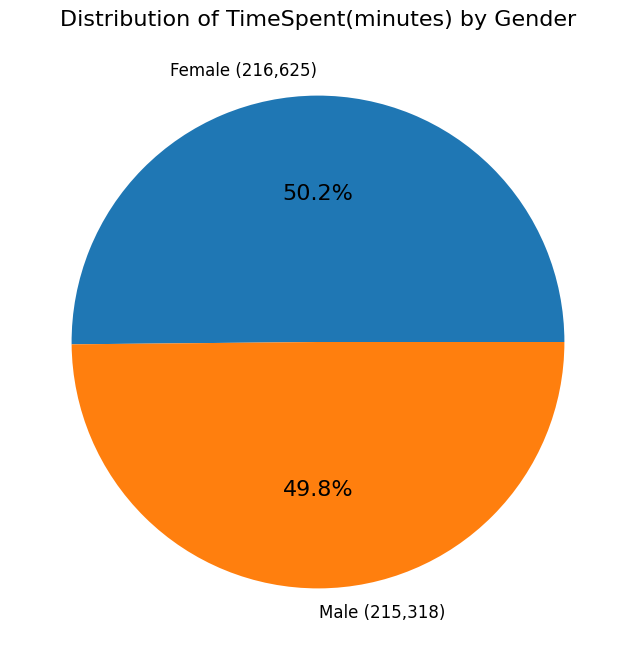

In [18]:
# Group by Gender and sum the TimeSpentOnWebsite
segment_sums = df.groupby('Gender')['TimeSpent(minutes)'].sum()

# Plot a pie chart of TimeSpentOnWebsite against Gender
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of TimeSpent(minutes) by Gender')
plt.show()

The key insight we gain from this is that there is the possibility that Females spend more time on the website as compared to males which is slightly higher.

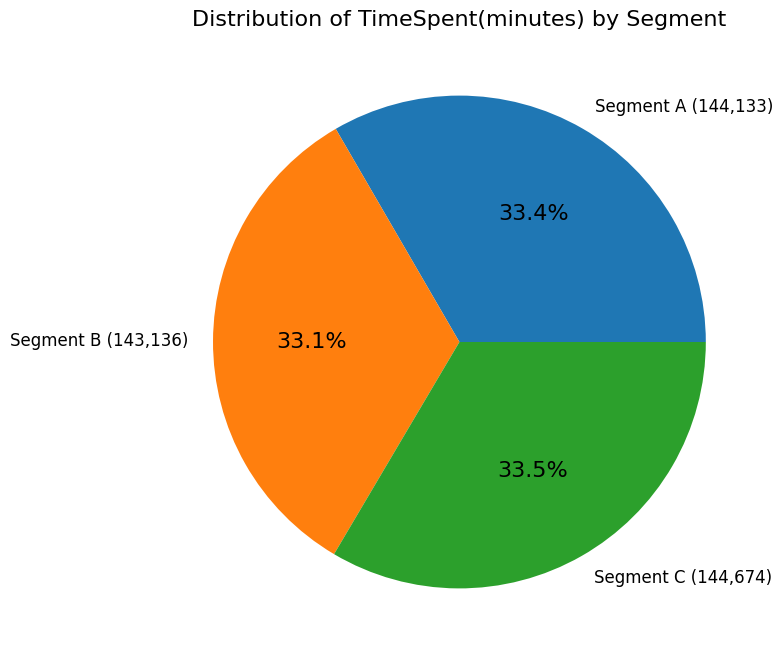

In [19]:
# Group by Segment and sum the TimeSpentOnWebsite
segment_sums = df.groupby('Segment')['TimeSpent(minutes)'].sum()

# Plot a pie chart of TimeSpentOnWebsite against Segment
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of TimeSpent(minutes) by Segment')
plt.show()

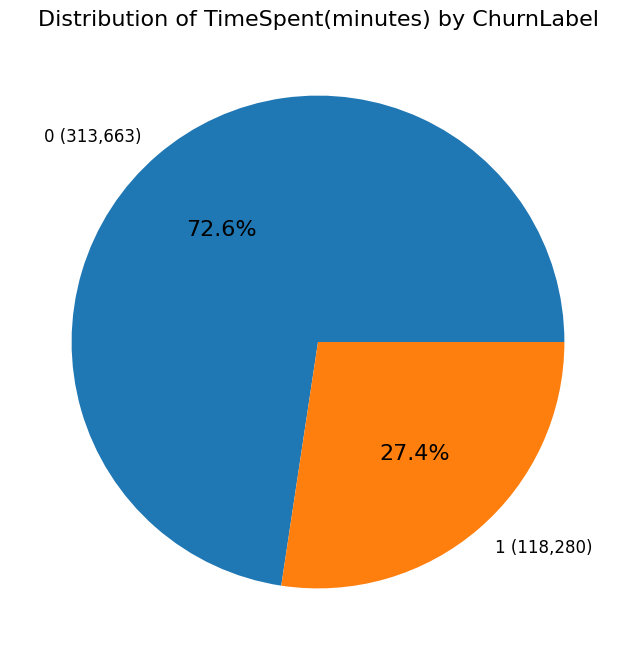

In [20]:
# Group by Churn Label and sum the TimeSpentOnWebsite
segment_sums = df.groupby('ChurnLabel')['TimeSpent(minutes)'].sum()

# Plot a pie chart of TimeSpentOnWebsite against ChurnLabel
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of TimeSpent(minutes) by ChurnLabel')
plt.show()

The key insight here is than the time spent on the website came from customers who churned which is highly unexpected therefore further investigation needs to be conducted on this.

# Average Late Payment

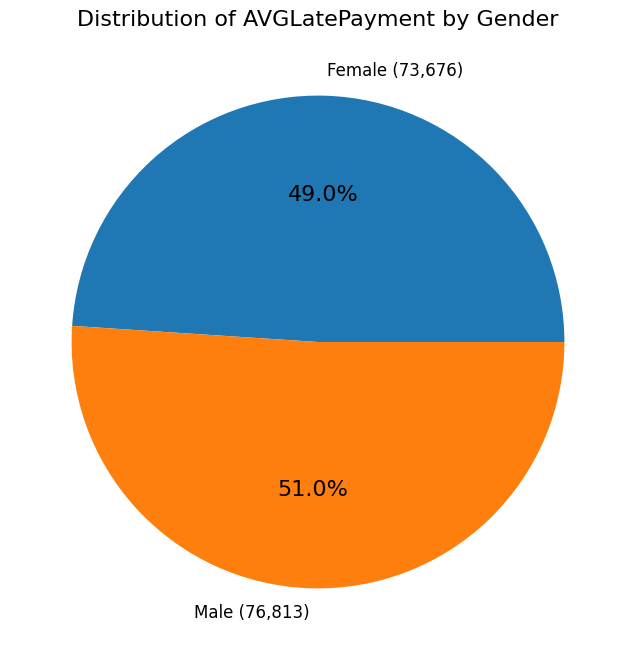

In [21]:
# Group by Gender and sum the AVGLatePayment
segment_sums = df.groupby('Gender')['AVGLatePayment'].sum()

# Plot a pie chart of AVGLatePayment against Gender
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of AVGLatePayment by Gender')
plt.show()

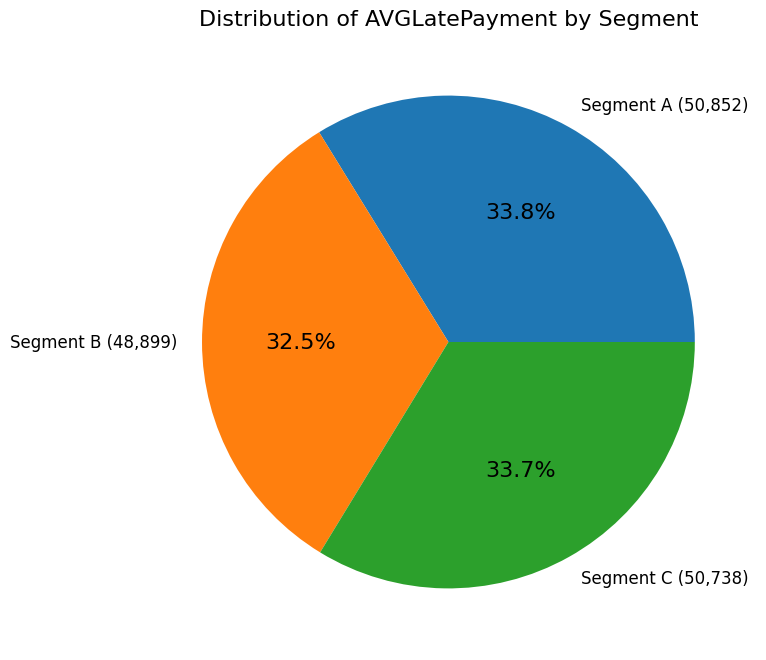

In [22]:
# Group by Segment and sum the AVGLatePayments
segment_sums = df.groupby('Segment')['AVGLatePayment'].sum()

# Plot a pie chart of AVGLatePayment against Segment
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of AVGLatePayment by Segment')
plt.show()

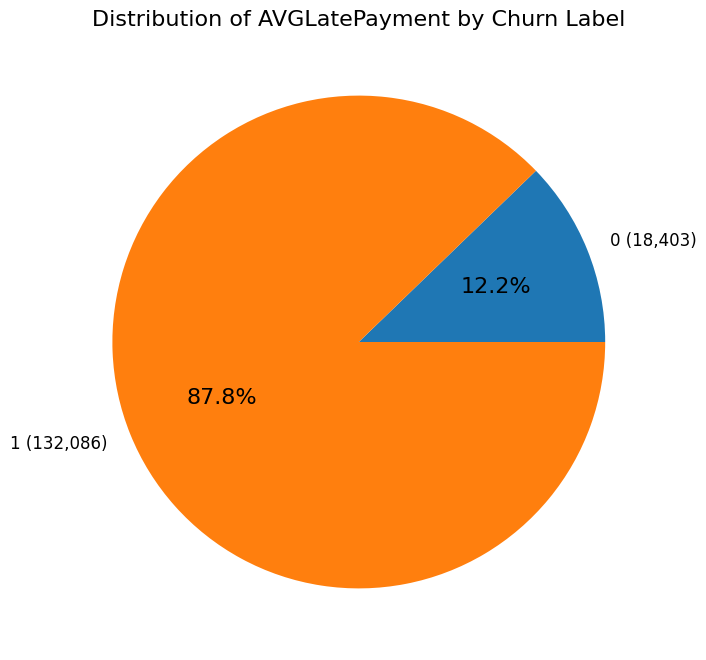

In [23]:
# Group by ChurnLabel and sum the AVGLatePayment
segment_sums = df.groupby('ChurnLabel')['AVGLatePayment'].sum()

# Plot a pie chart of AVGLatePayment against Churn Label
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of AVGLatePayment by Churn Label')
plt.show()

The key insight is that customer churn is associated with higher average late payments, as most late payments are concentrated among customers who churned (86.8%).

# Page Views

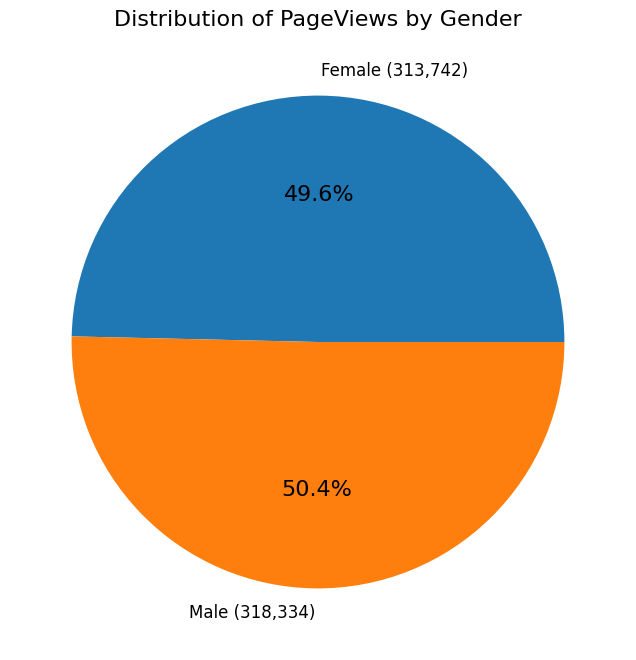

In [24]:
# Group by Gender and sum the PageViews
segment_sums = df.groupby('Gender')['PageViews'].sum()

# Plot a pie chart of TotalPageViews against Gender
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of PageViews by Gender')
plt.show()

The key insight we gain from this is that there is the possibility that Males have the most page views as compared to Females.


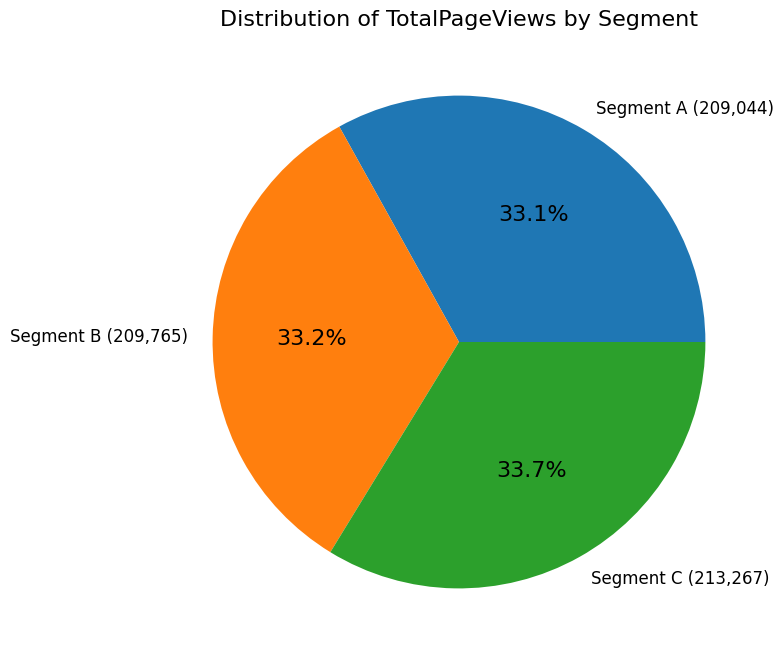

In [25]:
# Group by Segment and sum the PageViews
segment_sums = df.groupby('Segment')['PageViews'].sum()

# Plot a pie chart of TotalPageViews against Segment
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of TotalPageViews by Segment')
plt.show()

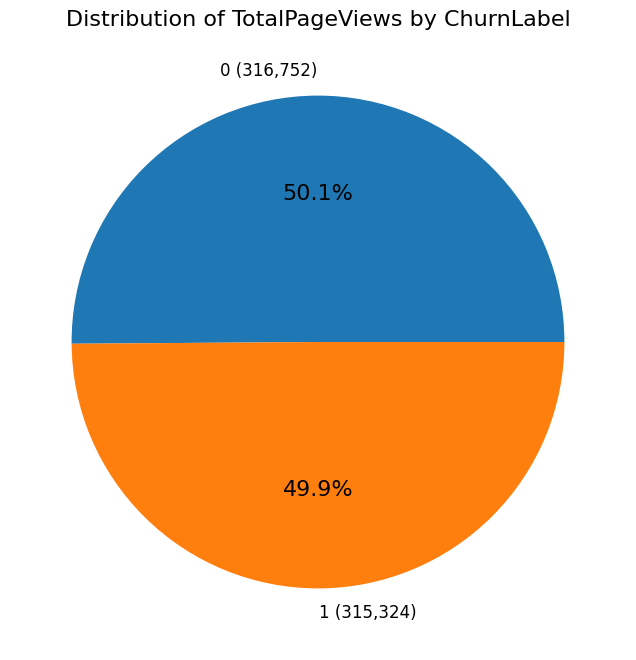

In [26]:
# Group by ChurnLabel and sum the PageViews
segment_sums = df.groupby('ChurnLabel')['PageViews'].sum()

# Plot a pie chart of TotalPageViews against Segment
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of TotalPageViews by ChurnLabel')
plt.show()

# Total Purchase Frequency

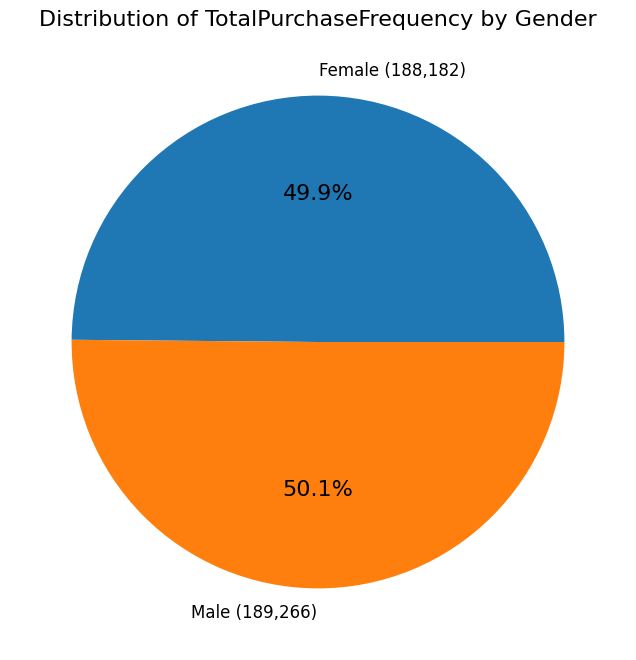

In [27]:
# Group by Gender and sum the TotalPurchaseFrequency   
segment_sums = df.groupby('Gender')['TotalPurchaseFrequency'].sum()

# Plot a pie chart of TotalPurchaseFrequency against Gender
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of TotalPurchaseFrequency by Gender')
plt.show()

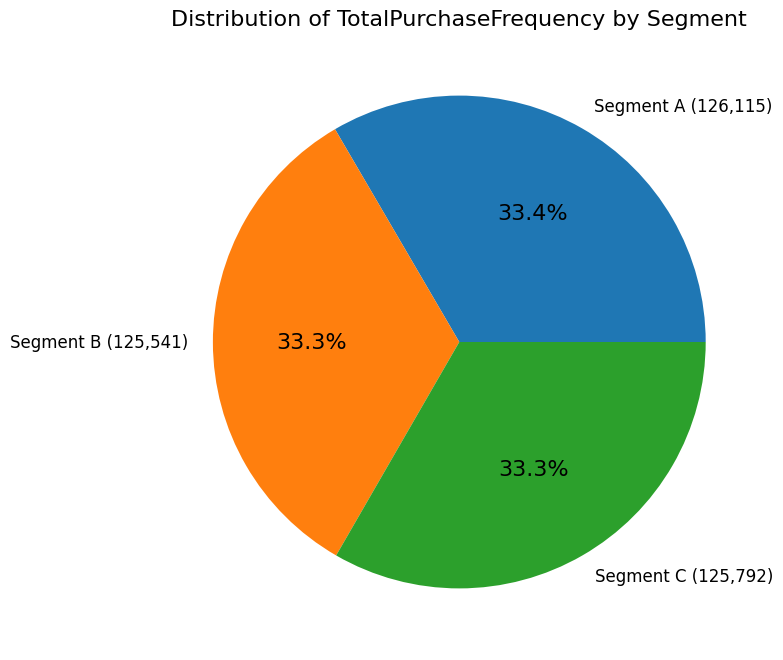

In [28]:
# Group by Segment and sum the TotalPurchaseFrequency
segment_sums = df.groupby('Segment')['TotalPurchaseFrequency'].sum()

# Plot a pie chart of TotalPurchaseFrequency against Segment
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of TotalPurchaseFrequency by Segment')
plt.show()

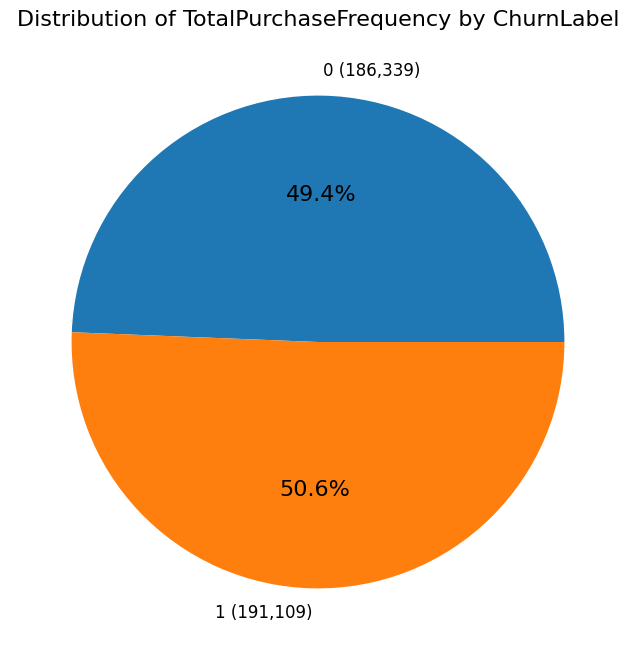

In [29]:
# Group by ChurnLabel and sum the TotalPurchaseFrequency
segment_sums = df.groupby('ChurnLabel')['TotalPurchaseFrequency'].sum()

# Plot a pie chart of TotalPageViews against Segment
# Add totals to labels
labels = [f"{seg} ({val:,.0f})" for seg, val in segment_sums.items()]

plt.figure(figsize=(8, 8))
plt.pie(segment_sums, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of TotalPurchaseFrequency by ChurnLabel')
plt.show()

In [30]:
nominal_columns = ['Gender', 'TotalInteractionType', 'Frequency'] # One hot encoding
ordinal_columns = ['Segment', 'Plan'] # label encoding
high_cardinality_columns = ['Location', 'ProductList'] # mean encoding

In [31]:
ohe = OneHotEncoder(sparse_output=False)

encode_data = df.copy()

encoded_columns = []

for col in nominal_columns:
    transformed_col = ohe.fit_transform(encode_data[[col]])
    transformed_df = pd.DataFrame(transformed_col, columns= [f"{col}_{cat}" for cat in ohe.categories_[0]])
    
    encoded_columns.append(transformed_df)

encode_data = pd.concat([encode_data] + encoded_columns, axis=1)
encode_data.drop(nominal_columns, axis=1, inplace=True)

In [32]:
le = LabelEncoder()

for col in ordinal_columns:
    encode_data[col] = le.fit_transform(encode_data[col])

In [33]:
for col in high_cardinality_columns:
    encode_data[col] = encode_data.groupby(col)['TotalPurchaseValue'].transform('mean')

In [34]:
encode_data.drop(columns='customer_segment', inplace=True)

In [35]:
encode_data

,CustomerID,Name,Age,Location,Email,Phone,Address,Segment,NPS,ChurnLabel,...,TotalInteractionType_Call,TotalInteractionType_Call|Chat,TotalInteractionType_Call|Chat|Email,TotalInteractionType_Call|Email,TotalInteractionType_Chat,TotalInteractionType_Chat|Email,TotalInteractionType_Email,Frequency_Daily,Frequency_Monthly,Frequency_Weekly
0,1001,Mark Barrett,31,3155.595000,allison74@example.net,3192528777,"61234 Shelley Heights Suite 467\nCohentown, GU...",1,3,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1002,Jeremy Welch,66,1477.077500,fmiller@example.com,231-587-1818x8651,"4959 Jennifer Junction\nNew Angelaport, TN 87397",2,6,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1003,Brandon Patel,36,1866.520000,jasonbrown@example.org,(270)633-9095,"38701 Amanda Brook Apt. 076\nKimshire, NJ 62516",1,3,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1004,Tina Martin,62,2473.600000,matthew62@example.net,050.081.8706x11982,"67324 Ashley Coves\nSouth John, RI 29650",2,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1005,Christopher Rodriguez,68,3795.523750,shannonstrickland@example.org,+1-701-854-4915x724,"01169 Miller Mission\nWest Anthonyburgh, WY 47359",2,3,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12478,13479,Catherine Lee,55,1196.560000,kgarcia@example.com,(977)150-1569x426,"836 Gonzalez Drive Apt. 334\nLake Kelly, RI 01667",0,8,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12479,13480,Kimberly Johnson,29,710.570000,carrjennifer@example.org,485.014.7824x5235,3715 Wiggins Harbors Suite 139\nEast Gregorybo...,0,7,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12480,13481,Lisa Rodgers,38,5154.420000,william37@example.com,951-489-9554,"56050 Steven Summit Suite 383\nJohnmouth, NM 2...",2,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12481,13482,Kristin Carey,26,3856.435000,josephcarter@example.net,001-335-464-3236x722,"72356 Teresa Rapid\nPorterborough, SC 40076",0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [36]:
date_col_to_engineer = encode_data.select_dtypes(include='datetime64').columns.to_list()
for col in date_col_to_engineer:
    encode_data[col + '_Year'] = encode_data[col].dt.year
    encode_data[col + '_Month'] = encode_data[col].dt.month
    encode_data[col + '_Day'] = encode_data[col].dt.day

    encode_data.drop(columns = col, inplace=True)

In [37]:
pd.set_option('display.max_columns', None)

In [38]:
encode_data

,CustomerID,Name,Age,Location,Email,Phone,Address,Segment,NPS,ChurnLabel,Timestamp,TotalPurchaseFrequency,TotalPurchaseValue,ProductList,Plan,Start_Date,End_Date,numEmails,numCalls,numChats,FirstInteractionDate,LastInteractionDate,AVGLatePayment,NumPaymentMethods,PageViews,TimeSpent(minutes),ActionCount,unique_pages,most_recent_action_date,Logins,Rating,Comment,AVGOpenDays,AVGClickDays,Gender_Female,Gender_Male,TotalInteractionType_Call,TotalInteractionType_Call|Chat,TotalInteractionType_Call|Chat|Email,TotalInteractionType_Call|Email,TotalInteractionType_Chat,TotalInteractionType_Chat|Email,TotalInteractionType_Email,Frequency_Daily,Frequency_Monthly,Frequency_Weekly
0,1001,Mark Barrett,31,3155.595000,allison74@example.net,3192528777,"61234 Shelley Heights Suite 467\nCohentown, GU...",1,3,1,2020-01-27 01:36:49,38,3994.72,3994.720000,6,2020-06-08,2022-10-27,1,1,2,2019-09-26,2021-07-25,13.333333,3,49,15,24,13,2022-11-07 02:24:31,19,1,I move baby go small big. Office institution s...,818.0,319.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1002,Jeremy Welch,66,1477.077500,fmiller@example.com,231-587-1818x8651,"4959 Jennifer Junction\nNew Angelaport, TN 87397",2,6,0,2019-01-06 18:30:03,4,2844.35,2844.350000,12,2021-07-21,2022-05-07,10,5,4,2019-01-12,2022-12-13,3.333333,3,100,9,24,13,2022-12-05 00:27:08,9,2,Wish what bag cut life. Statement might opport...,110.0,88.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1003,Brandon Patel,36,1866.520000,jasonbrown@example.org,(270)633-9095,"38701 Amanda Brook Apt. 076\nKimshire, NJ 62516",1,3,0,2019-04-30 04:25:10,14,1866.52,1866.520000,5,2019-10-05,2020-08-19,1,1,1,2019-10-09,2022-01-04,2.666667,3,1,97,12,7,2022-11-02 15:59:43,19,4,Some Democrat guess but short. Whether behind ...,333.0,117.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1004,Tina Martin,62,2473.600000,matthew62@example.net,050.081.8706x11982,"67324 Ashley Coves\nSouth John, RI 29650",2,1,1,2020-03-03 17:33:28,28,1378.64,1378.640000,15,2020-01-14,2022-03-27,18,17,24,2019-01-03,2022-11-10,26.333333,3,25,31,47,14,2022-12-08 18:10:18,4,1,Yard feel never miss ask billion Congress. Fly...,159.0,423.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1005,Christopher Rodriguez,68,3795.523750,shannonstrickland@example.org,+1-701-854-4915x724,"01169 Miller Mission\nWest Anthonyburgh, WY 47359",2,3,0,2019-04-05 22:42:22,39,2425.05,2425.050000,0,2021-04-08,2022-11-09,5,4,1,2019-04-10,2022-12-19,0.666667,3,77,51,30,12,2022-12-30 23:37:00,12,3,Ten determine unit interview challenge stock. ...,193.0,96.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12478,13479,Catherine Lee,55,1196.560000,kgarcia@example.com,(977)150-1569x426,"836 Gonzalez Drive Apt. 334\nLake Kelly, RI 01667",0,8,0,2022-01-27 00:27:28,14,1196.56,1196.560000,5,2019-06-15,2021-06-29,3,3,4,2019-05-07,2022-10-09,1.000000,3,70,57,6,6,2022-10-02 14:18:14,22,2,Light appear fight lawyer where star.,126.0,443.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12479,13480,Kimberly Johnson,29,710.570000,carrjennifer@example.org,485.014.7824x5235,3715 Wiggins Harbors Suite 139\nEast Gregorybo...,0,7,0,2020-06-14 23:04:47,1,710.57,523.136667,8,2022-12-10,2022-12-28,0,1,2,2019-12-11,2022-11-05,2.000000,3,71,66,9,8,2022-11-10 14:12:37,25,3,Yet very girl history. Thing late dream you re...,167.0,40.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12480,13481,Lisa Rodgers,38,5154.420000,william37@example.com,951-489-9554,"56050 Steven Summit Suite 383\nJohnmouth, NM 2...",2,1,1,2020-10-13 15:09:13,63,5154.42,5154.420000,2,2021-07-04,2021-07-24,11,9,6,2019-01-12,2022-12-08,27.666667,3,96,1,26,9,2022-11-20 23:26:42,9,5,Offer particularly single degree seem sound. S...,383.0,459.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12481,13482,Kristin Carey,26,3856.435000,josephcarter@exam

In [39]:
# Remove all categorical columns from encoded data
categorical_columns = encode_data.select_dtypes(include=['object']).columns.to_list()
print(categorical_columns)
encode_data.drop(columns=categorical_columns, inplace=True)

['Name', 'Email', 'Phone', 'Address', 'Timestamp', 'Start_Date', 'End_Date', 'FirstInteractionDate', 'LastInteractionDate', 'most_recent_action_date', 'Comment']


In [40]:
encode_data.to_csv('clean_train_data.csv', index=False)

## Finished encoding data, thus ready for model training